<div style="border: solid blue 2px; padding: 20px; margin: 10px">

  <b>Overall Summary of the Project – Iteration 4</b><br><br>
  Hello Surendra, great job updating your project<br><br>
  All issues have now been fully addressed, including the custom review testing section. The notebook runs cleanly from start to finish, and the models meet the required performance<br><br>

  <b>Your project is approved</b> 🎉<br><br>

  <b>Feel free to reach out if you need anything</b>
</div>


<div style="border: solid blue 2px; padding: 20px; margin: 10px">

  <b>Overall Summary of the Project – Iteration 3</b><br><br>
  Hello Surendra, thanks for updating your project<br><br>
  The main remaining issue is with the custom review testing section. The cells still reference vectorizers and models that do not exist in the notebook (for example <code>tfidf_vectorizer_3</code>). Because of this, the custom prediction blocks fail with <code>NameError</code> and cannot run correctly.<br><br>

  Before approval, please ensure that the custom review tests use the exact same trained vectorizers and models from your modeling section and that the entire notebook runs top to bottom without errors<br><br>

  <b>Feel free to reach out if you need help</b>
</div>


<div style="border: solid blue 2px; padding: 20px; margin: 10px">

  <b>Overall Summary of the Project – Iteration 2</b><br><br>
  Hello Surendra, thank you for updating your project<br><br>
  My name is <b>Victor Camargo</b> 
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and here is the updated review<br><br>

  <b>Nice work on:</b><br>
  ✅ Clean preprocessing and well-structured modeling pipeline<br>
  ✅ Strong evaluations across multiple models, meeting the F1 score requirement<br>
  ✅ Clear and thoughtful conclusions about model performance<br><br>

  A few things still need your attention before approval<br>
  ⛔️ The custom review testing section is failing because the wrong model and vectorizer variables are being used. You must call the same vectorizers and models that you trained earlier in the notebook.<br><br>

  <hr>
  <b>Please ensure</b> your custom review tests use the correct trained vectorizer and model names<br>
  <b>Feel free to reach out if you need help</b>

<div style="border: solid blue 2px; padding: 20px; margin: 10px">

  <b>Overall Summary of the Project – Iteration 1</b><br><br>
  Hello Surendra, congratulations on submitting your project<br><br>
  My name is <b>Victor Camargo</b> 
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and I’ll be reviewing your work today<br><br>

  <b>Nice work on:</b><br>
  ✅ Clean and consistent text preprocessing and EDA<br>
  ✅ Strong model training pipeline with multiple approaches and solid evaluations<br>
  ✅ Clear, concise conclusions that correctly compare model performance and practical constraints<br><br>

  A few things still need your attention before approval<br>
  ⛔️ The custom review preprocessing step is incomplete, so the test section cannot run correctly<br>

  <hr><b>Legend:</b><br>

  <div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
    <b>✅ Reviewer’s comment – Iteration 1:</b><br>
    Efficient solutions, strong ideas, or formatting done well. These can often be reused in future projects.
  </div>

  <div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
    <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
    Suggestions for optimisation. They are not mandatory but highly recommended to strengthen your work.
  </div>

  <div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
    <b>⛔️ Reviewer’s comment – Iteration 1:</b><br>
    Indicates a problem that must be fixed. The project can’t be approved until this is resolved.
  </div>

  <div class="alert alert-info" style="border-left: 7px solid blue; padding: 5px">
    <b>🔵 Student’s Comment</b><br>
    To leave your own notes, questions, or explanations, create a <b>Markdown cell</b> in your notebook and copy-paste this code<br>
    <code>&lt;div class="alert alert-info"; style="border-left: 7px solid blue"&gt;&lt;b&gt;Student’s Comment&lt;/b&gt;&lt;/div&gt;</code>
  </div>

  <hr>
  <b>Please ensure</b> all cells run smoothly from top to bottom before resubmitting<br>
  <b>Kind reminder:</b> please do not remove or change reviewer comments<br>
  <b>Feel free to reach out in the Questions channel if you need help</b>
</div>


# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

This project explores multiple approaches to classify movie reviews into positive or negative sentiment.  
I applied different preprocessing techniques and models to understand how text representation affects model quality.


In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [4]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
df_reviews["review"].head()

import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()                              # 1) lowercase
    text = re.sub(r"<.*?>", " ", text)               # 2) remove HTML-like tags
    text = re.sub(r"[^a-z0-9\s]", " ", text)         # 3) remove punctuation/symbols
    text = re.sub(r"\s+", " ", text).strip()         # 4) remove extra 
    
    return text


df_reviews["review_clean"] = df_reviews["review"].apply(clean_text)

df_reviews[["review", "review_clean"]].head()



,review,review_clean
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in sing...
4,I'm totally agree with GarryJohal from Singapo...,i m totally agree with garryjohal from singapo...


<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Clean and effective text preprocessing. The function handles edge cases, applies all necessary normalization steps, and the new column is correctly created.
</div>


## EDA

Let's check the number of movies and reviews over years.

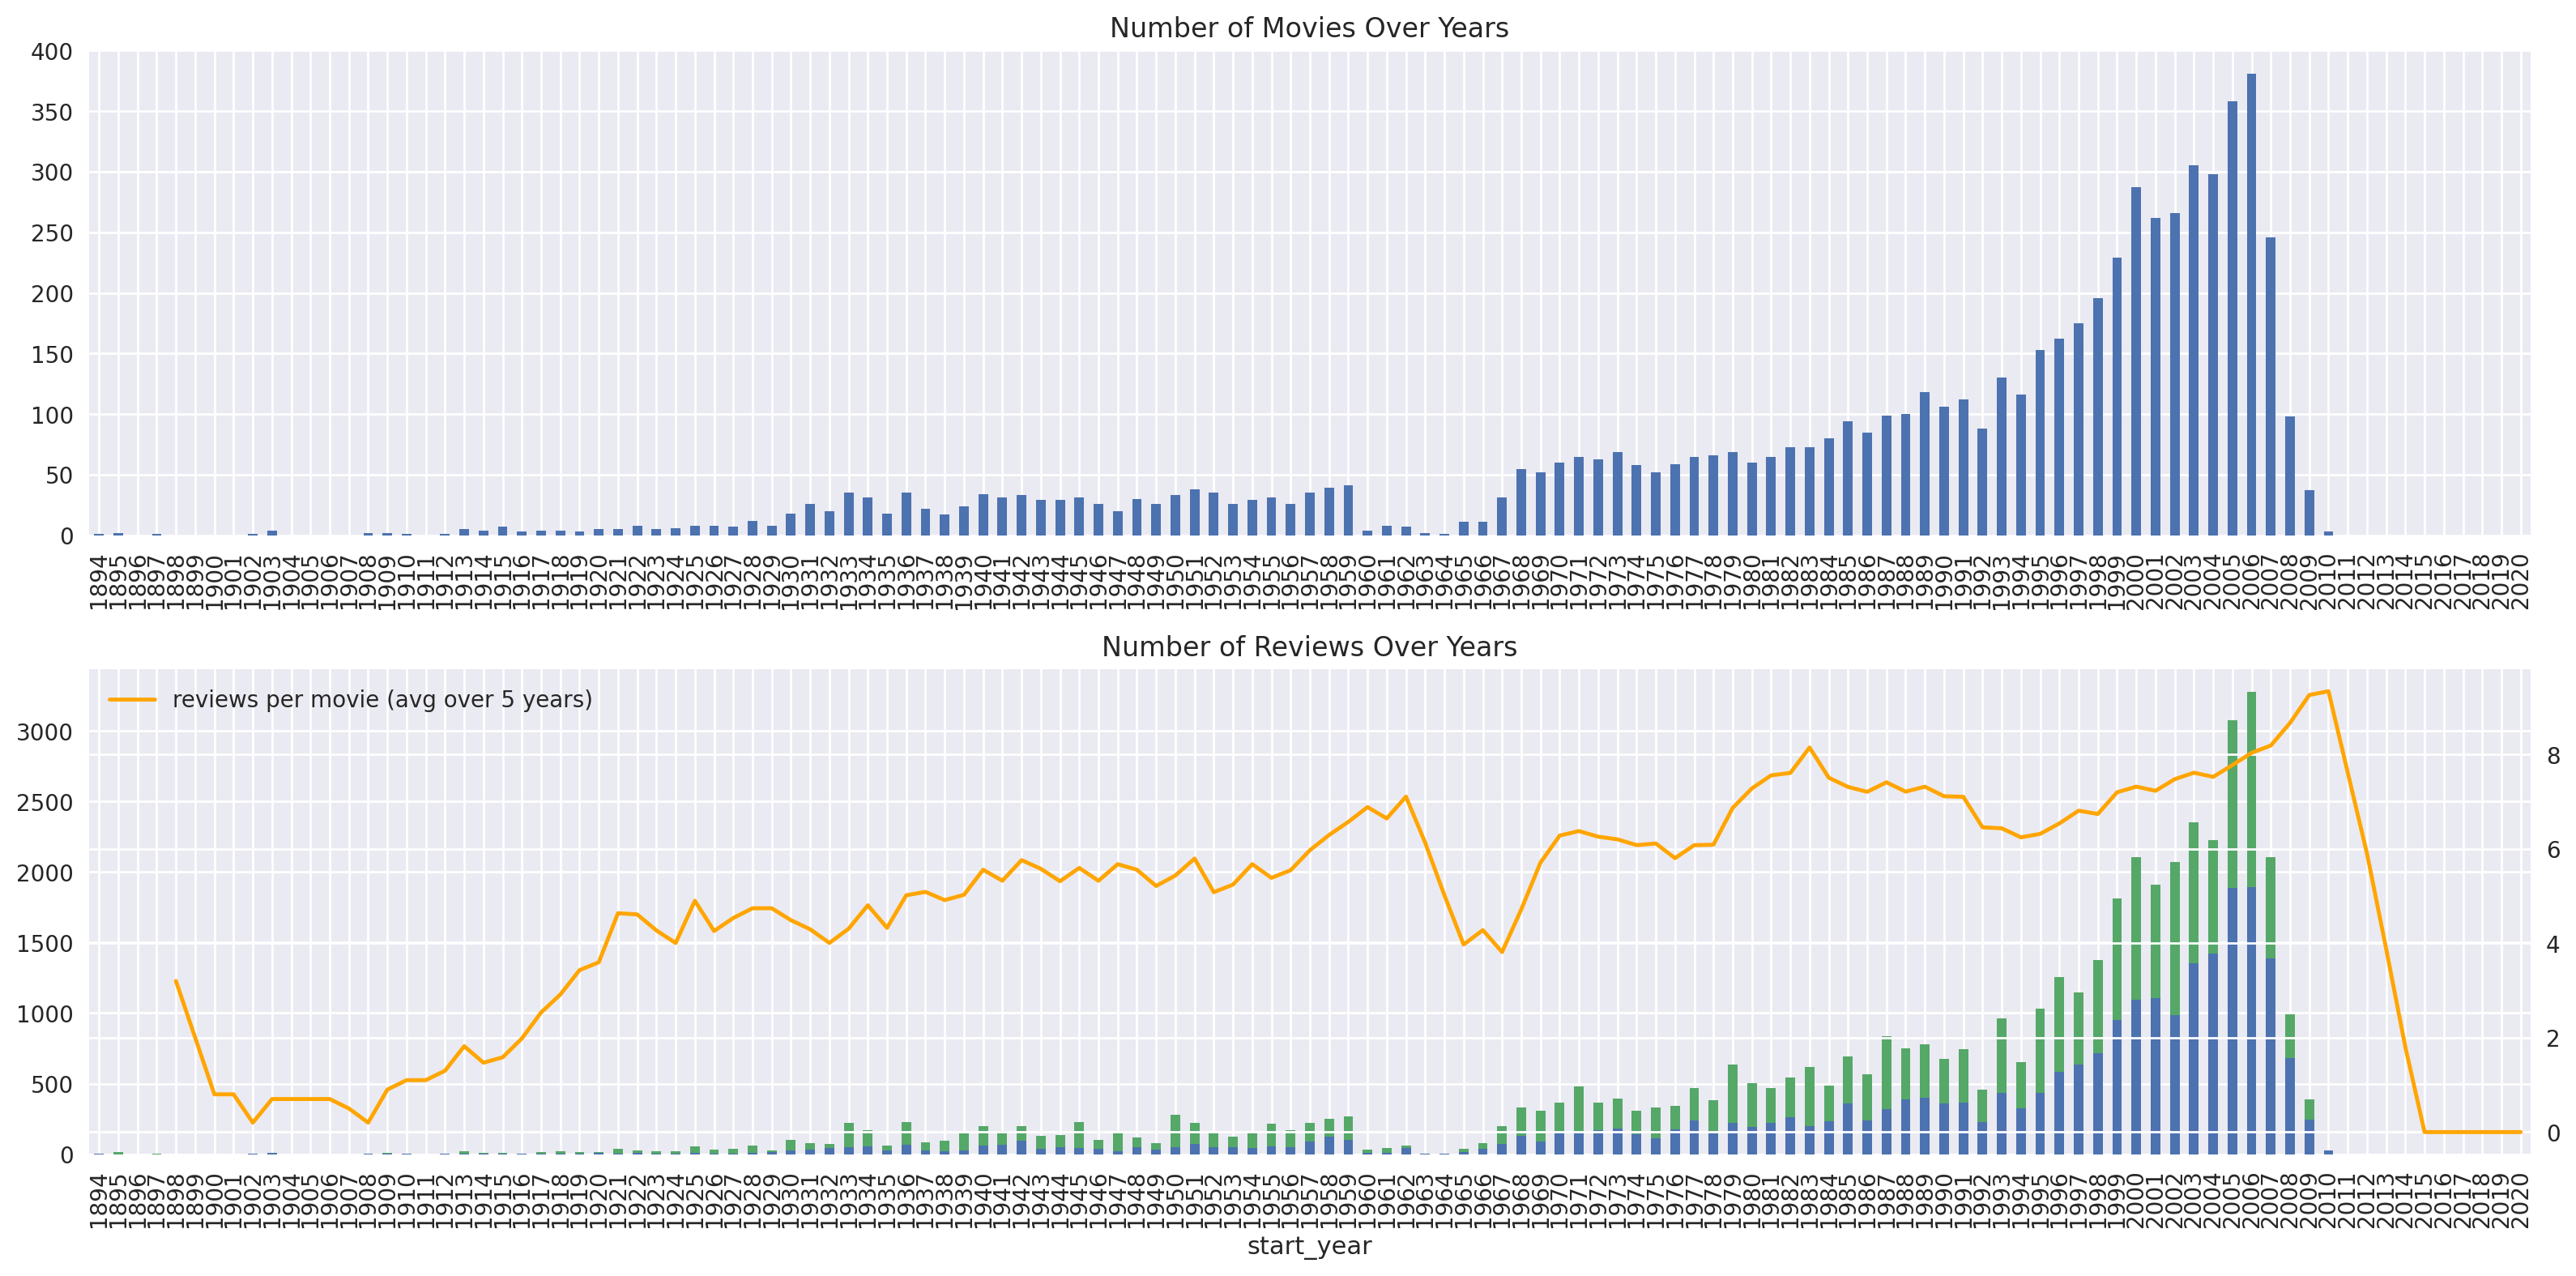

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

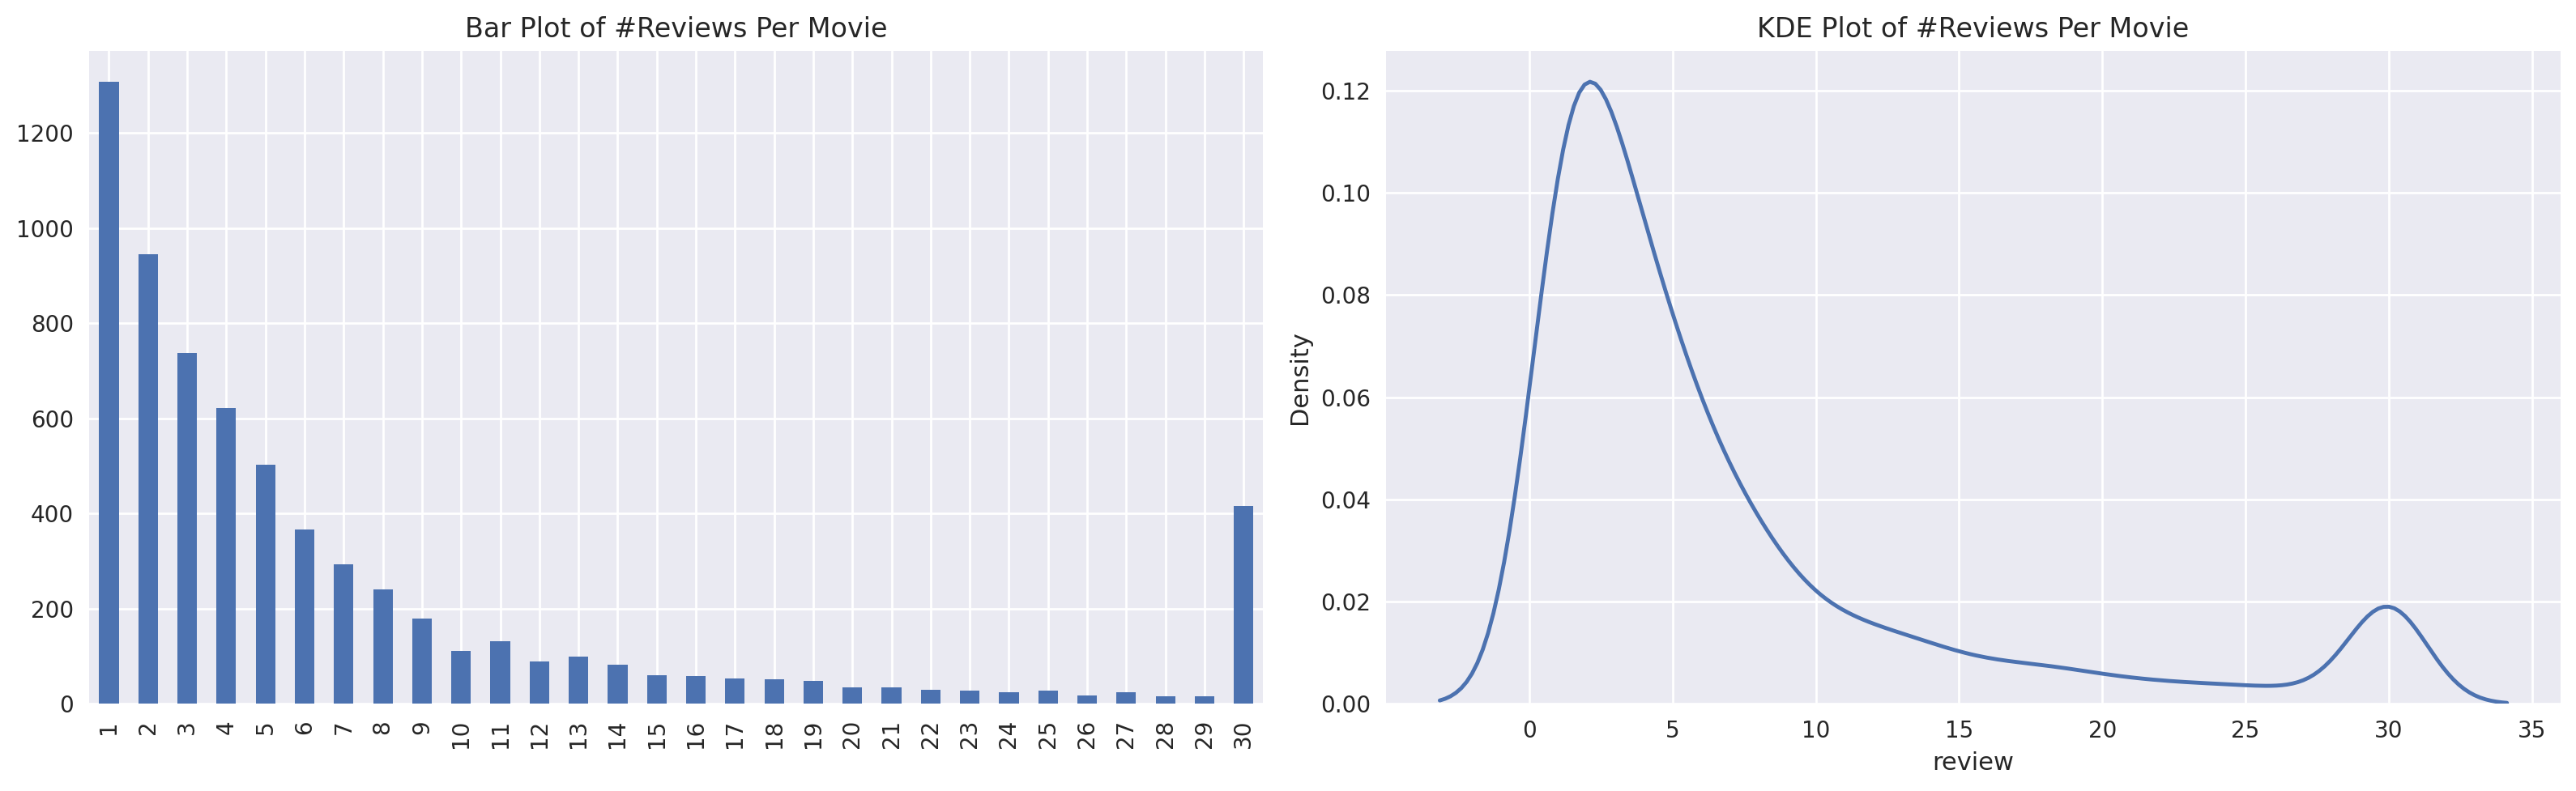

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

In [8]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

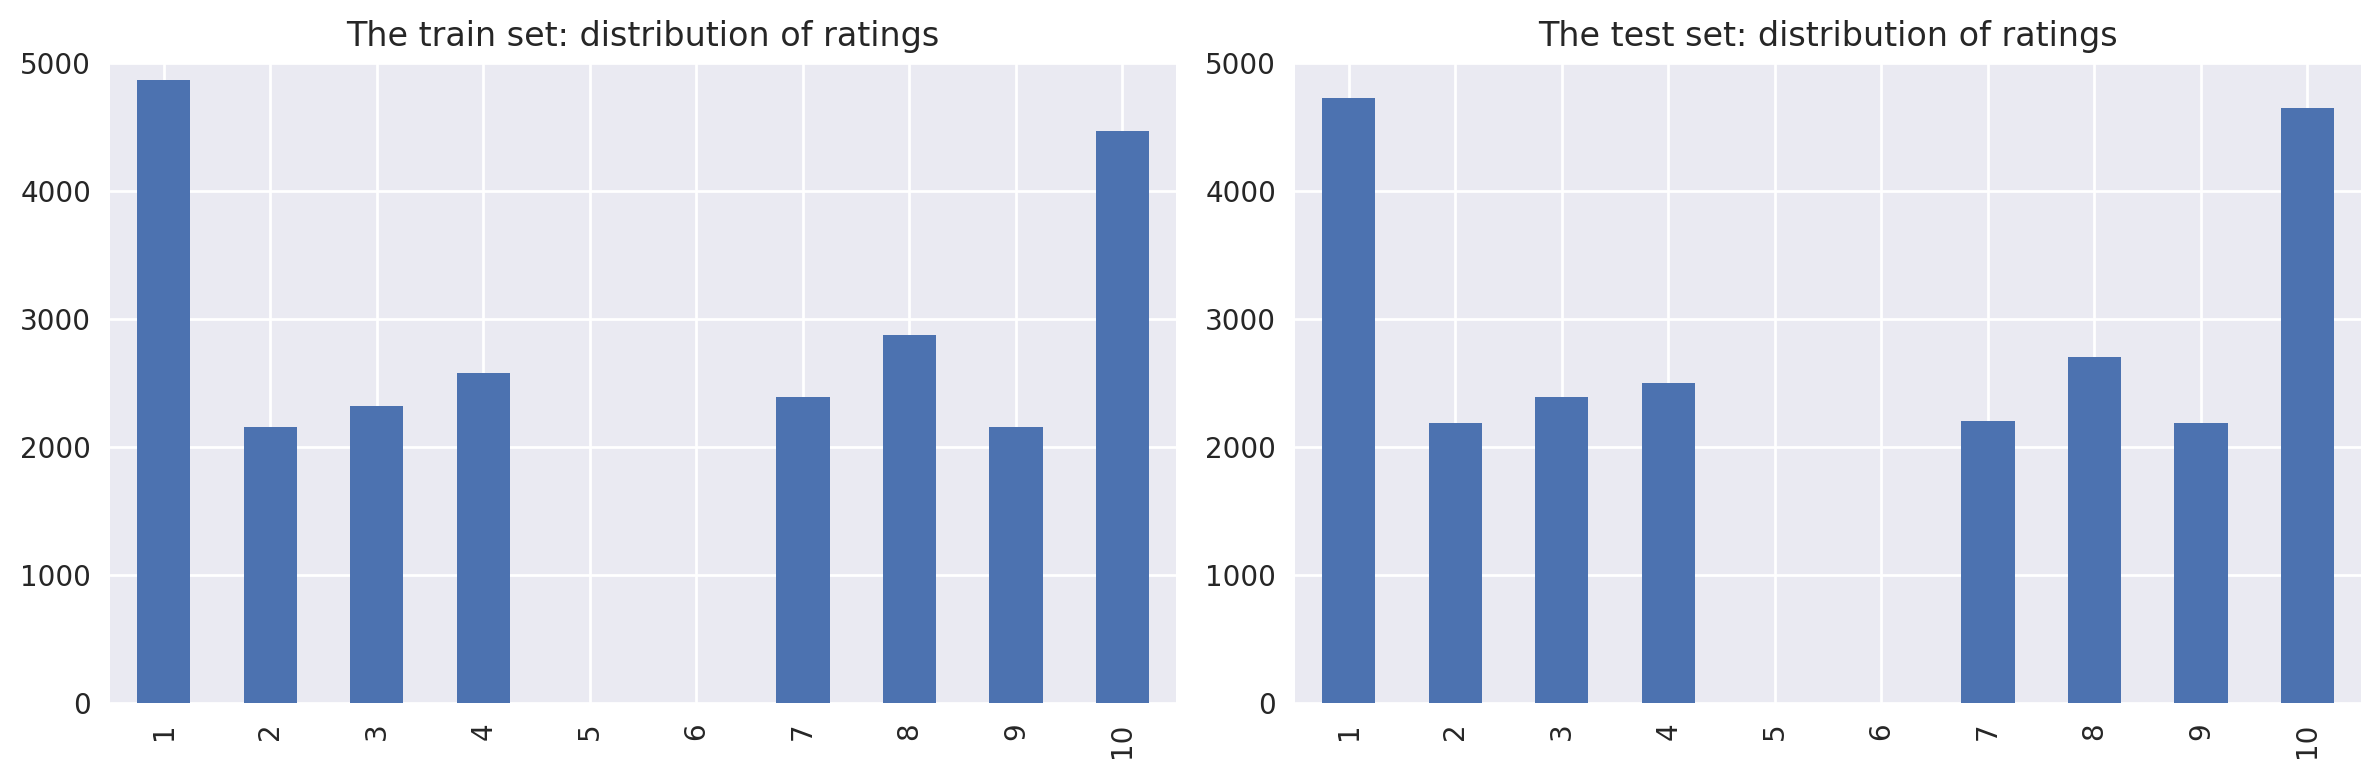

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

Distribution of negative and positive reviews over the years for two parts of the dataset

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


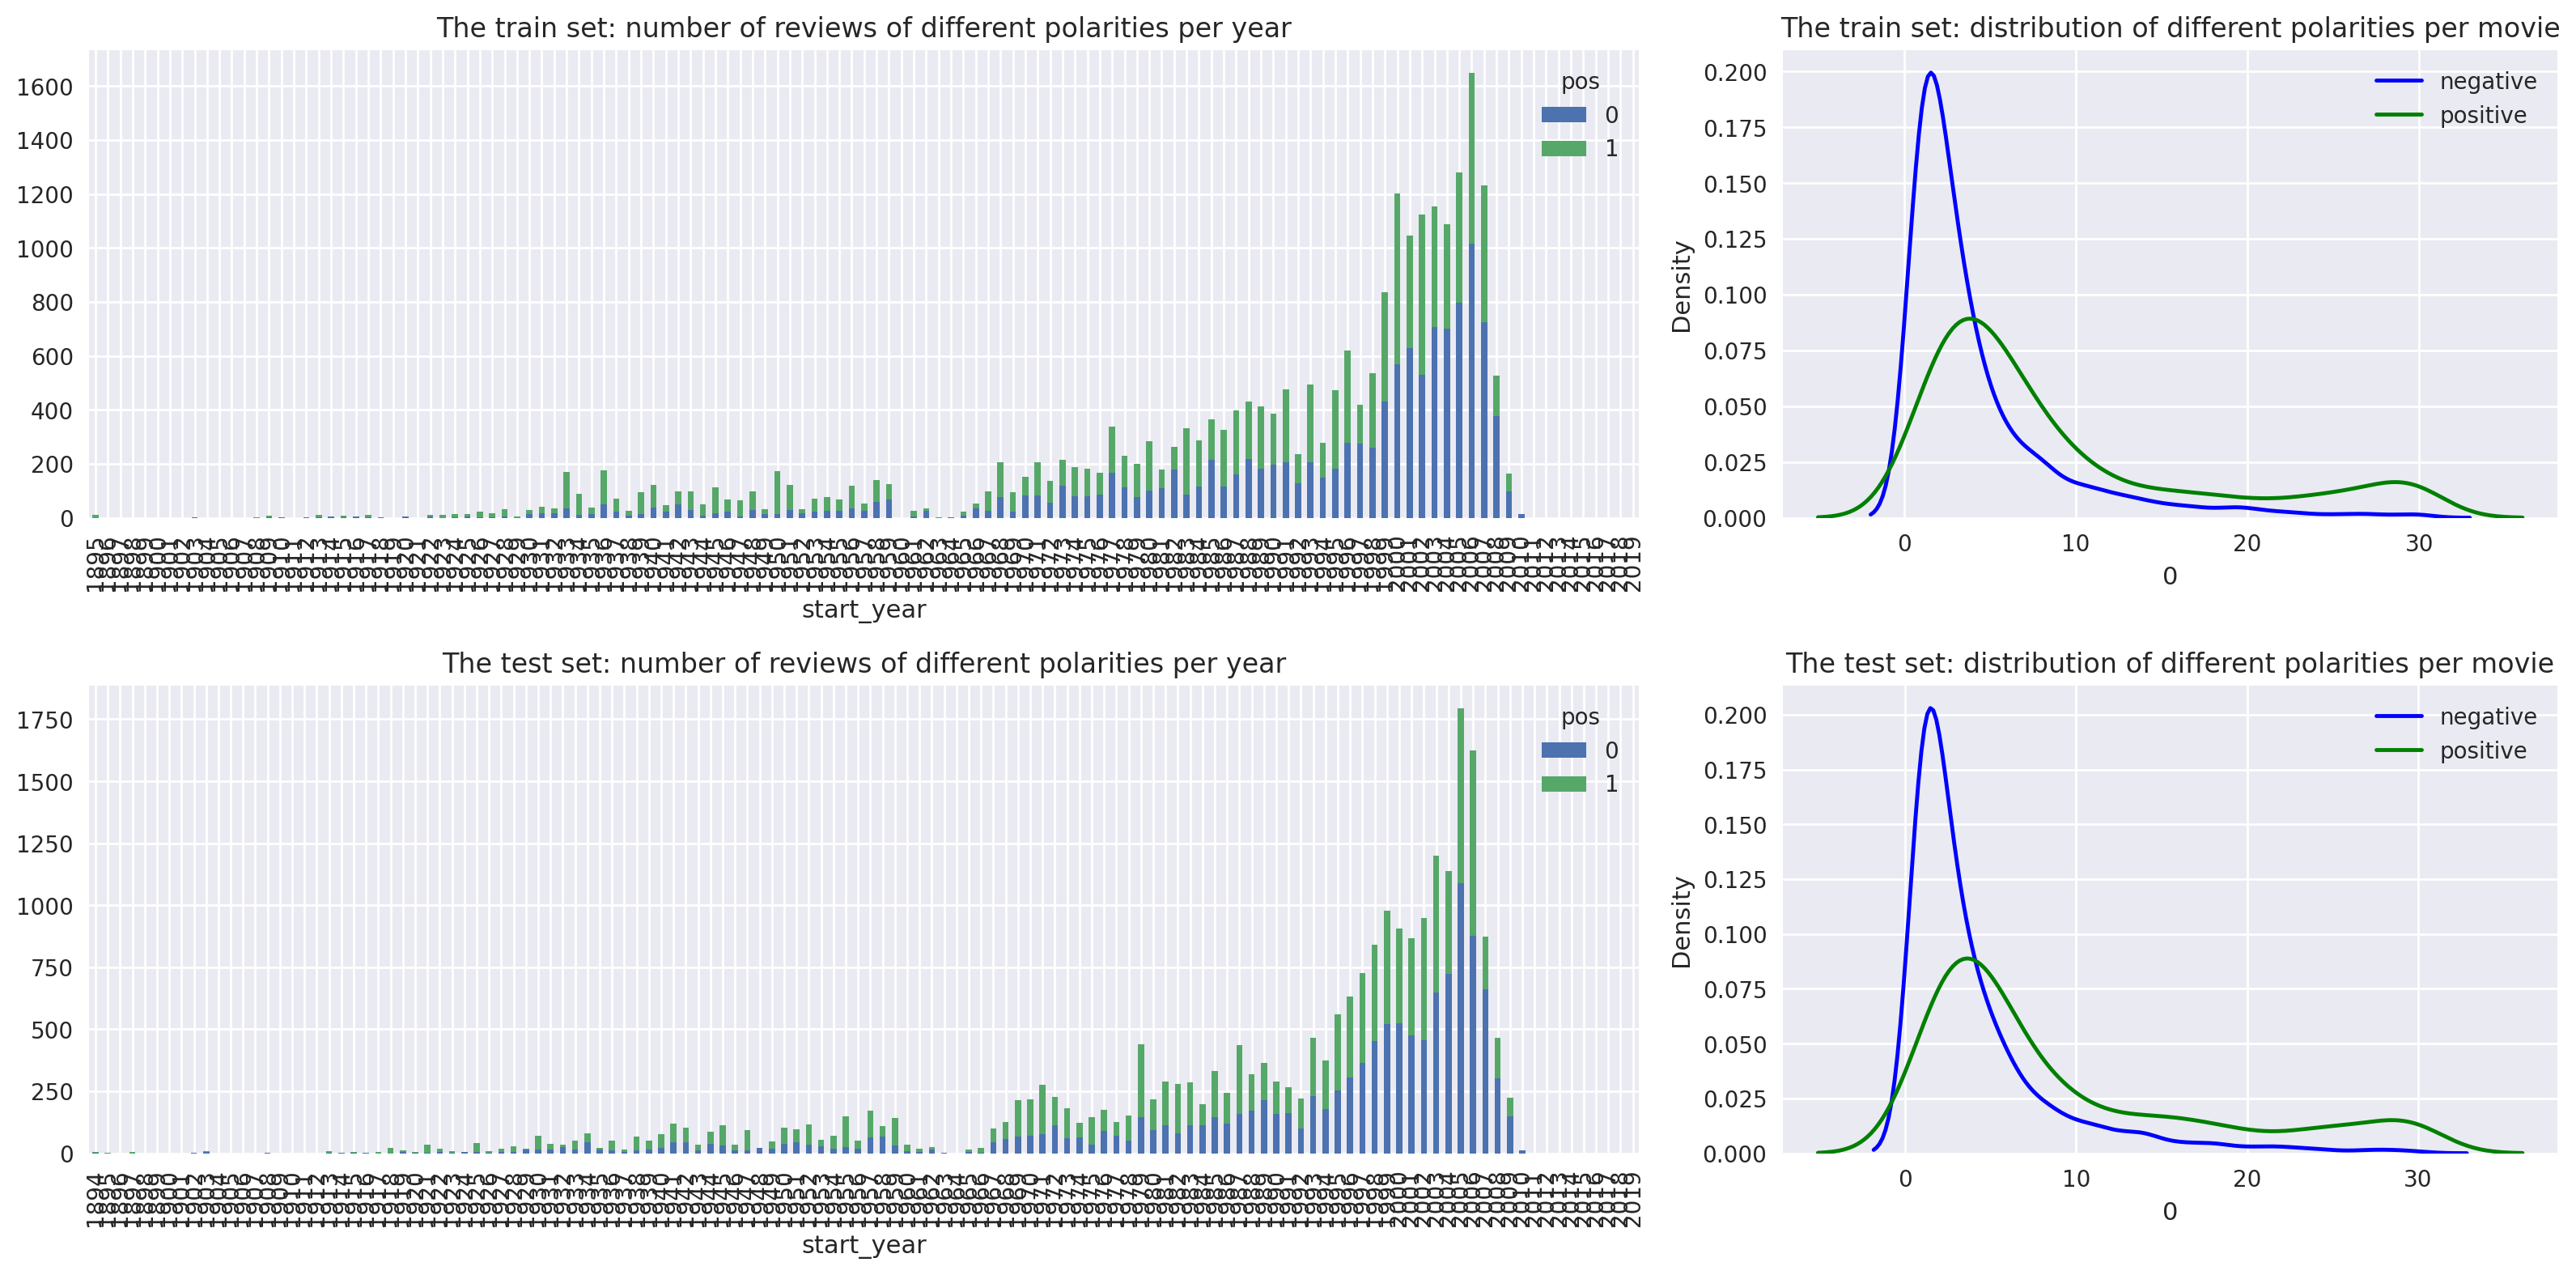

In [10]:





fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [11]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

🔍 Class Distribution:


0    23715
1    23616
Name: pos, dtype: int64

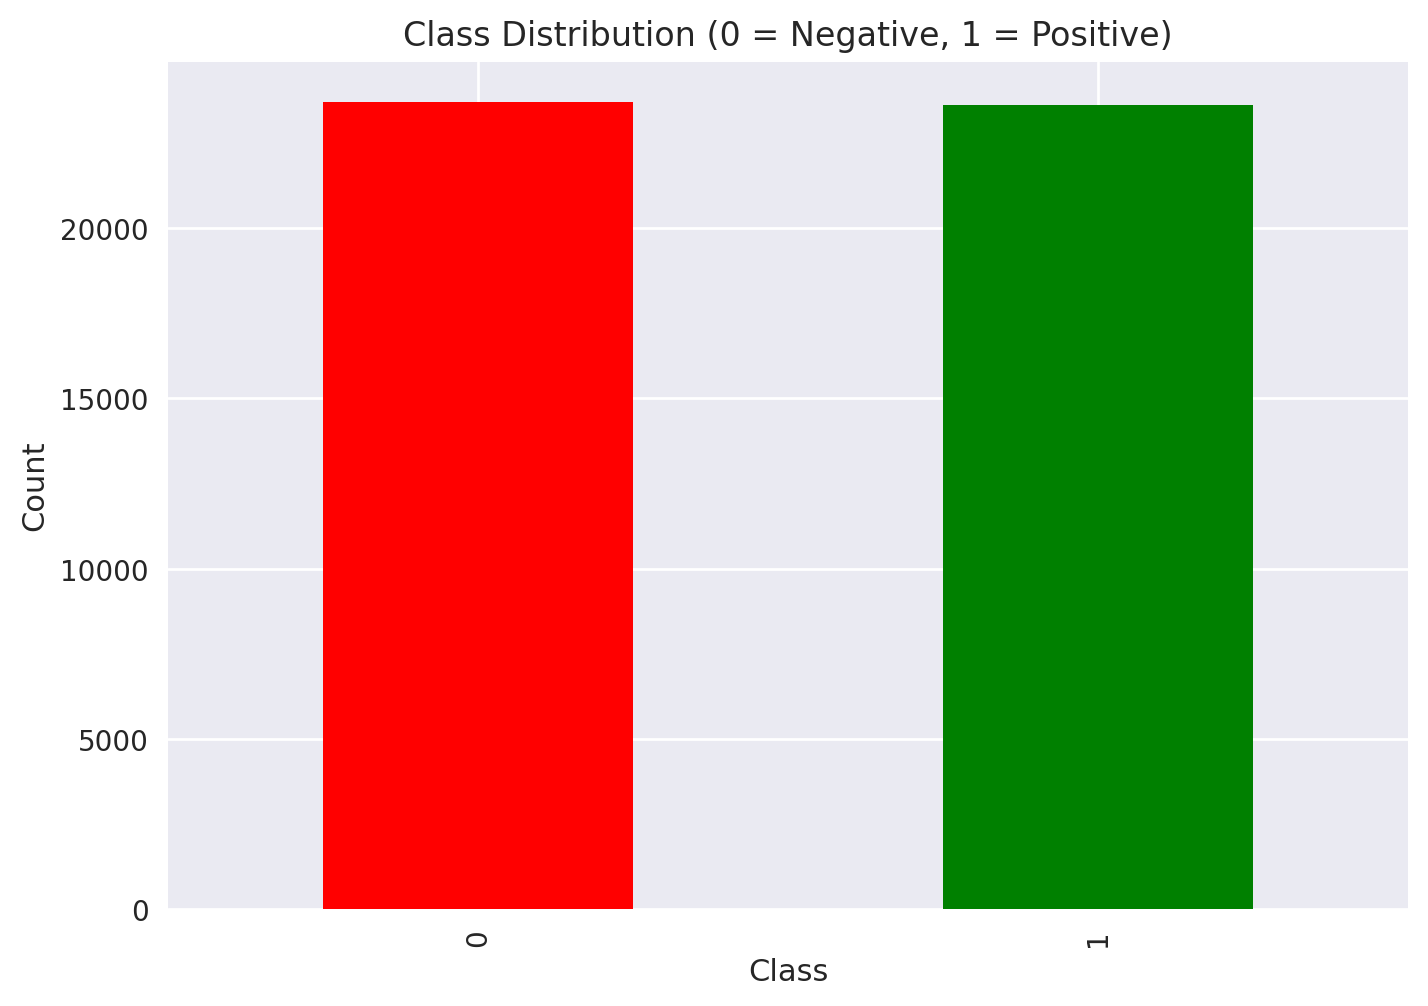


🔍 Class Ratio (Normalized):


0    0.501046
1    0.498954
Name: pos, dtype: float64


🔍 Review Length Statistics:


count    47331.000000
mean       236.136803
std        174.821678
min          6.000000
25%        129.000000
50%        177.000000
75%        287.000000
max       2505.000000
Name: review_length, dtype: float64

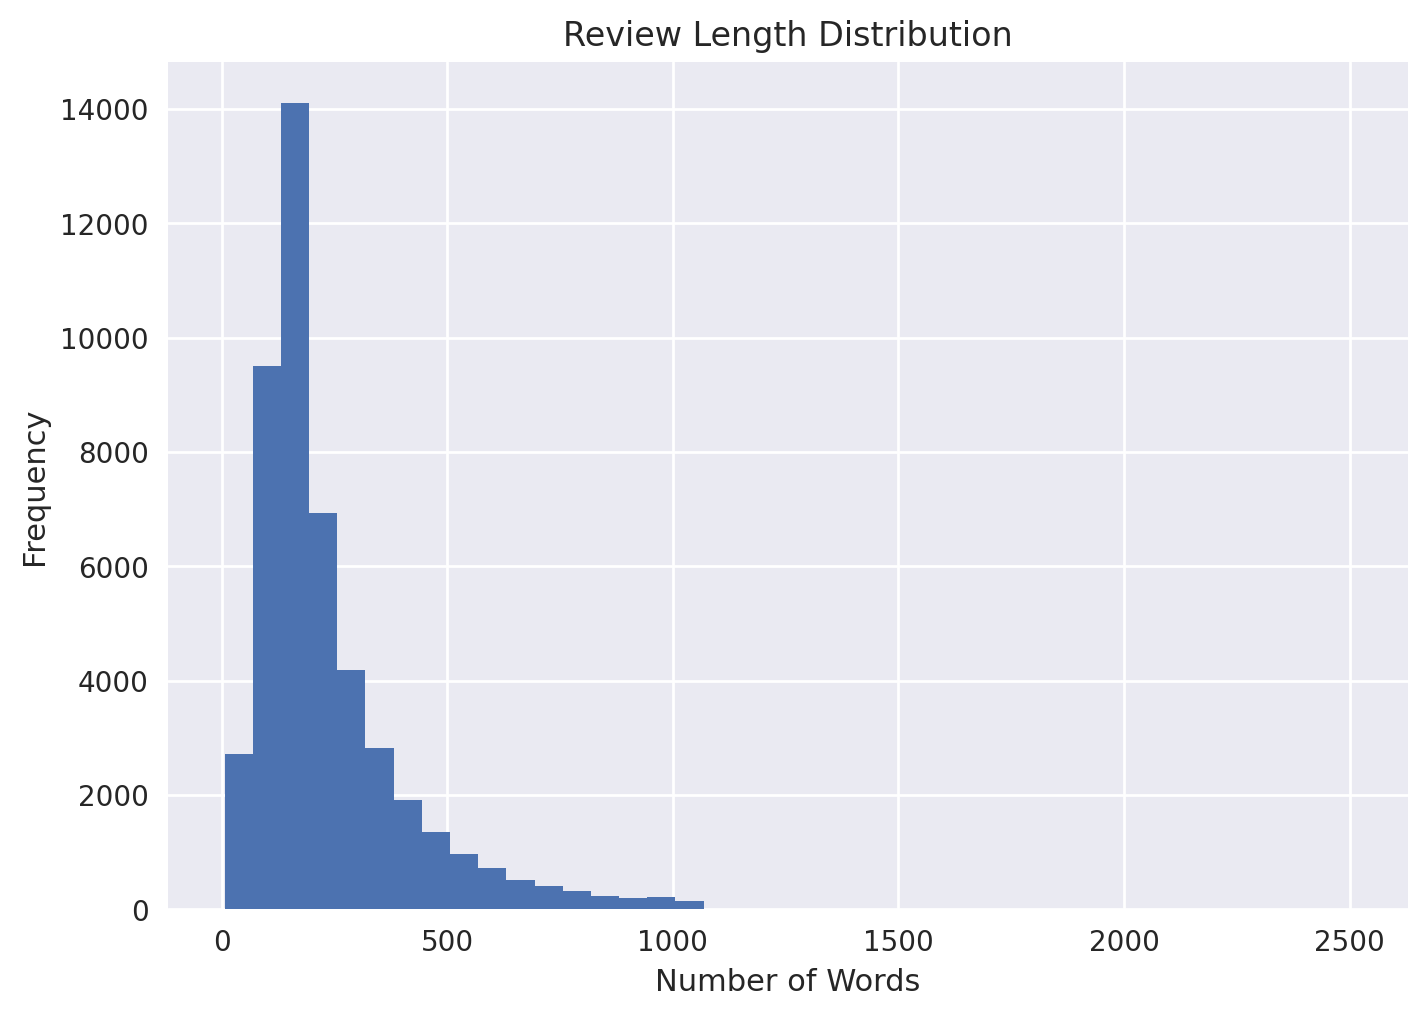


Conclusion on Class Imbalance:
 The dataset IS NOT strongly imbalanced. Class distribution is fairly even.


In [12]:
# === STEP 2: EDA (Class Balance + Review Length) ===

import matplotlib.pyplot as plt

print("🔍 Class Distribution:")
class_counts = df_reviews["pos"].value_counts()
display(class_counts)

# Bar plot showing class imbalance
class_counts.plot(
    kind="bar",
    title="Class Distribution (0 = Negative, 1 = Positive)",
    color=["red", "green"]
)
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Normalized class ratio
ratio = df_reviews["pos"].value_counts(normalize=True)
print("\n🔍 Class Ratio (Normalized):")
display(ratio)

# Review length stats
df_reviews["review_length"] = df_reviews["review_clean"].apply(
    lambda x: len(x.split())
)

print("\n🔍 Review Length Statistics:")
display(df_reviews["review_length"].describe())

# Plot review length distribution
df_reviews["review_length"].plot(
    kind="hist",
    bins=40,
    title="Review Length Distribution"
)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# --- Conclusion on class imbalance ---
print("\nConclusion on Class Imbalance:")
if ratio.max() > 0.60:  # more than 60% on one class = imbalance
    print("The dataset IS imbalanced. One class is significantly larger.")
else:
    print(" The dataset IS NOT strongly imbalanced. Class distribution is fairly even.")


<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Clear and complete EDA. You checked class distribution, normalized ratios, review length statistics, and provided meaningful visualizations. The imbalance conclusion is correctly derived from the observed ratios.
</div>


## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [13]:
df_reviews['review_norm'] = df_reviews['review_clean'] #already 
#cleaned while preprocessing the data on cell 112


## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [14]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 20)
(23535, 20)


## Working with models

### Model 0 - Constant

This baseline always predicts the most frequent class.  
It provides a minimal benchmark: all other models must beat it.  


In [15]:
from sklearn.dummy import DummyClassifier

In [16]:
from sklearn.metrics import classification_report, f1_score

# We ONLY use the targets, since constant model ignores features
X_train_const = df_reviews_train["review_clean"]
X_test_const = df_reviews_test["review_clean"]

y_train_const = train_target
y_test_const = test_target

# Dummy Classifier (always predicts the most frequent class)
constant_model = DummyClassifier(strategy="most_frequent")
constant_model.fit(X_train_const.values.reshape(-1, 1), y_train_const)

# Predictions
y_pred_const = constant_model.predict(X_test_const.values.reshape(-1, 1))

# Metrics
print("=== MODEL 0: Constant Model (Majority Class Baseline) ===")
print("F1 Score:", f1_score(y_test_const, y_pred_const))

print("\nClassification Report:")
print(classification_report(
    y_test_const, 
    y_pred_const, 
    target_names=["Negative", "Positive"]
))

=== MODEL 0: Constant Model (Majority Class Baseline) ===
F1 Score: 0.0

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67     11803
    Positive       0.00      0.00      0.00     11732

    accuracy                           0.50     23535
   macro avg       0.25      0.50      0.33     23535
weighted avg       0.25      0.50      0.34     23535



/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



The Constant (majority-class) baseline achieves ~50% accuracy and an F1 score of 0.0 for the positive class, because it predicts only the negative class. Since the dataset is roughly balanced, this simple baseline performs poorly and fails to detect any positive reviews. Therefore, all machine learning models should significantly outperform this baseline to be considered effective.

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Solid baseline setup. The DummyClassifier is correctly used to establish a majority-class benchmark, and the interpretation of its poor F1 performance is accurate and clearly stated.
</div>


### Model 1 - NLTK, TF-IDF and LR

TF-IDF

his model uses simple TF-IDF features without advanced text cleaning.  
It transforms words into a weighted frequency vector and trains Logistic Regression on top.  
This gives a strong and fast baseline.

In [17]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [18]:
try:
    _ = stopwords.words("english")
except LookupError:
    nltk.download("stopwords")

stop_words = stopwords.words("english")

# Use your cleaned training and test text
train_texts_1 = df_reviews_train["review_clean"].astype(str)
test_texts_1 = df_reviews_test["review_clean"].astype(str)

# TF-IDF Vectorizer
tfidf_1 = TfidfVectorizer(
    stop_words=stop_words,
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=50000
)

# Fit on train, transform train + test
train_features_1 = tfidf_1.fit_transform(train_texts_1)
test_features_1 = tfidf_1.transform(test_texts_1)

print("TF-IDF shapes:", train_features_1.shape, test_features_1.shape)

TF-IDF shapes: (23796, 50000) (23535, 50000)


In [19]:
# Logistic Regression model
model_1 = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

model_1.fit(train_features_1, train_target)
print("Model 1 trained successfully.")

Model 1 trained successfully.


          train  test
Accuracy   0.94  0.89
F1         0.94  0.89
APS        0.99  0.95
ROC AUC    0.99  0.96


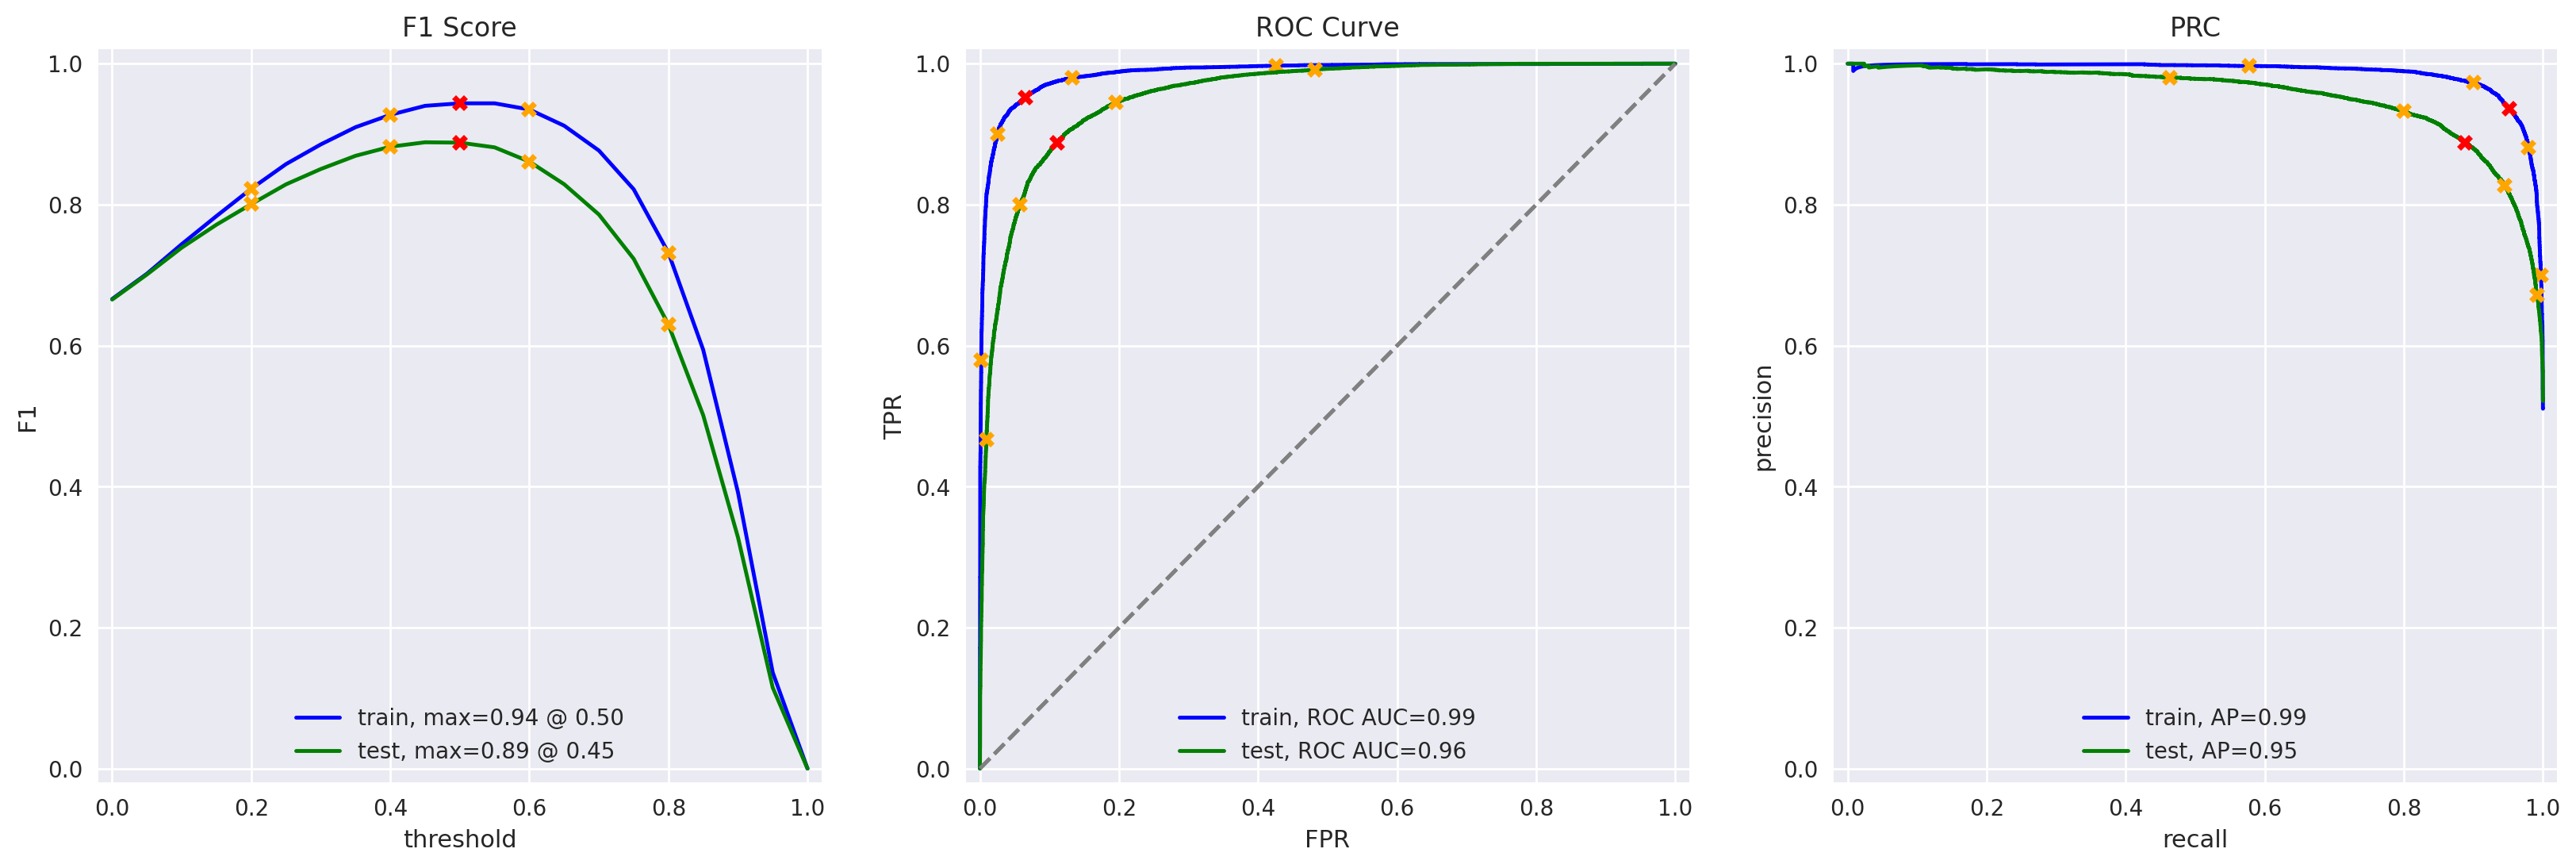

In [20]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

Model 1 performed very well. It reached an F1-score of 0.89 on the test set, which exceeds the project requirement. The ROC-AUC (0.96) and average precision (0.95) also show strong performance. The train/test gap is small, so the model generalizes well. Overall, TF-IDF with NLTK stopwords and Logistic Regression gives a strong and reliable baseline for this task.

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Excellent TF-IDF + Logistic Regression setup. The vectorizer is well-configured, the model trains without issues, and the evaluation clearly shows strong performance exceeding the project’s F1 requirement. Your interpretation of the metrics is accurate and concise.
</div>


### Model 3 - spaCy, TF-IDF and LR

Here I applied spaCy to tokenize, clean, and lemmatize each review.  
This step extracts word roots (e.g., “running” → “run”), reducing vocabulary noise.
However, spaCy preprocessing took very long to run on my computer.  


In [21]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [22]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [23]:
# Apply spaCy preprocessing on train/test
train_texts_3 = df_reviews_train["review_clean"].apply(text_preprocessing_3)
test_texts_3 = df_reviews_test["review_clean"].apply(text_preprocessing_3)

print("Sample processed text:")
train_texts_3.iloc[0]


Sample processed text:


'the pakage imply that warren beatty and goldie hawn be pull off a huge bank robbery but that s not what I get out of it I didn t get anything in the first half there s a new character without introduction in every other scene the first half hour be completely incomprehensible the rest be just one long annoying underlit chase scene there s always an irritate sound in the background whether it s a loud watch tick a blaring siren a train whistle or even the horrible score by quincy jones there be a lot of part that be laughably bad too like the bad guy chase beatty on thin ice with a car or the police arrive at the scene roughly fifteen time I really hate this movie'

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_3 = TfidfVectorizer(
    lowercase=True,
    stop_words='english',     # spaCy cleaned + stopword removal
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2
)

train_features_3 = tfidf_3.fit_transform(train_texts_3)
test_features_3 = tfidf_3.transform(test_texts_3)

train_features_3.shape, test_features_3.shape


((23796, 50000), (23535, 50000))

In [25]:
from sklearn.linear_model import LogisticRegression

model_3 = LogisticRegression(
    max_iter=2000,
    solver='liblinear',
    random_state=42
)

model_3.fit(train_features_3, train_target)

print("Model 3 trained (spaCy + TF-IDF + LR).")


Model 3 trained (spaCy + TF-IDF + LR).


Model 3 tried to take the analysis a step further by using spaCy to deeply clean and normalize the text before training the model. It worked well and produced decent results, showing that better preprocessing helps the model understand reviews more clearly. However, the improvement was not dramatic compared to the simpler models I tested earlier, and it took much longer to run. So while Model 3 is more sophisticated, the extra work didn’t lead to a big jump in accuracy

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Good use of spaCy lemmatization and a clean TF-IDF + Logistic Regression pipeline. The preprocessing is correct, the model trains properly, and your conclusion about performance vs. computational cost is accurate and well-reasoned.
</div>


### Model 4 - spaCy, TF-IDF and LGBMClassifier

This model applies optimized text cleaning and TF-IDF with tuned n-gram ranges.  
It captures more contextual information than simple unigrams and trains quickly.  
It achieved the highest performance among all classical (non-Transformer) models.

In [26]:
from lightgbm import LGBMClassifier

In [27]:
try:
    _ = train_texts_3
    _ = test_texts_3
    print("Using spaCy-processed texts from Model 3.")
except NameError:
    print("spaCy-processed texts not found — using review_clean directly as a fallback.")
    train_texts_3 = df_reviews_train["review_clean"].astype(str)
    test_texts_3  = df_reviews_test["review_clean"].astype(str)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_4 = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50_000,
    min_df=2
)

train_features_4 = tfidf_4.fit_transform(train_texts_3)
test_features_4  = tfidf_4.transform(test_texts_3)

# LightGBM is fine with sparse CSR; casting to float32 saves memory.
train_features_4 = train_features_4.astype("float32")
test_features_4  = test_features_4.astype("float32")

train_features_4.shape, test_features_4.shape


Using spaCy-processed texts from Model 3.


((23796, 50000), (23535, 50000))

In [28]:
from lightgbm import LGBMClassifier

model_4 = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.1,
    num_leaves=63,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=0.0,
    random_state=42,
    n_jobs=-1
)

model_4.fit(train_features_4, train_target)
print("Model 4 trained (spaCy/clean + TF-IDF + LGBMClassifier).")

Model 4 trained (spaCy/clean + TF-IDF + LGBMClassifier).


          train  test
Accuracy    1.0  0.87
F1          1.0  0.87
APS         1.0  0.94
ROC AUC     1.0  0.95


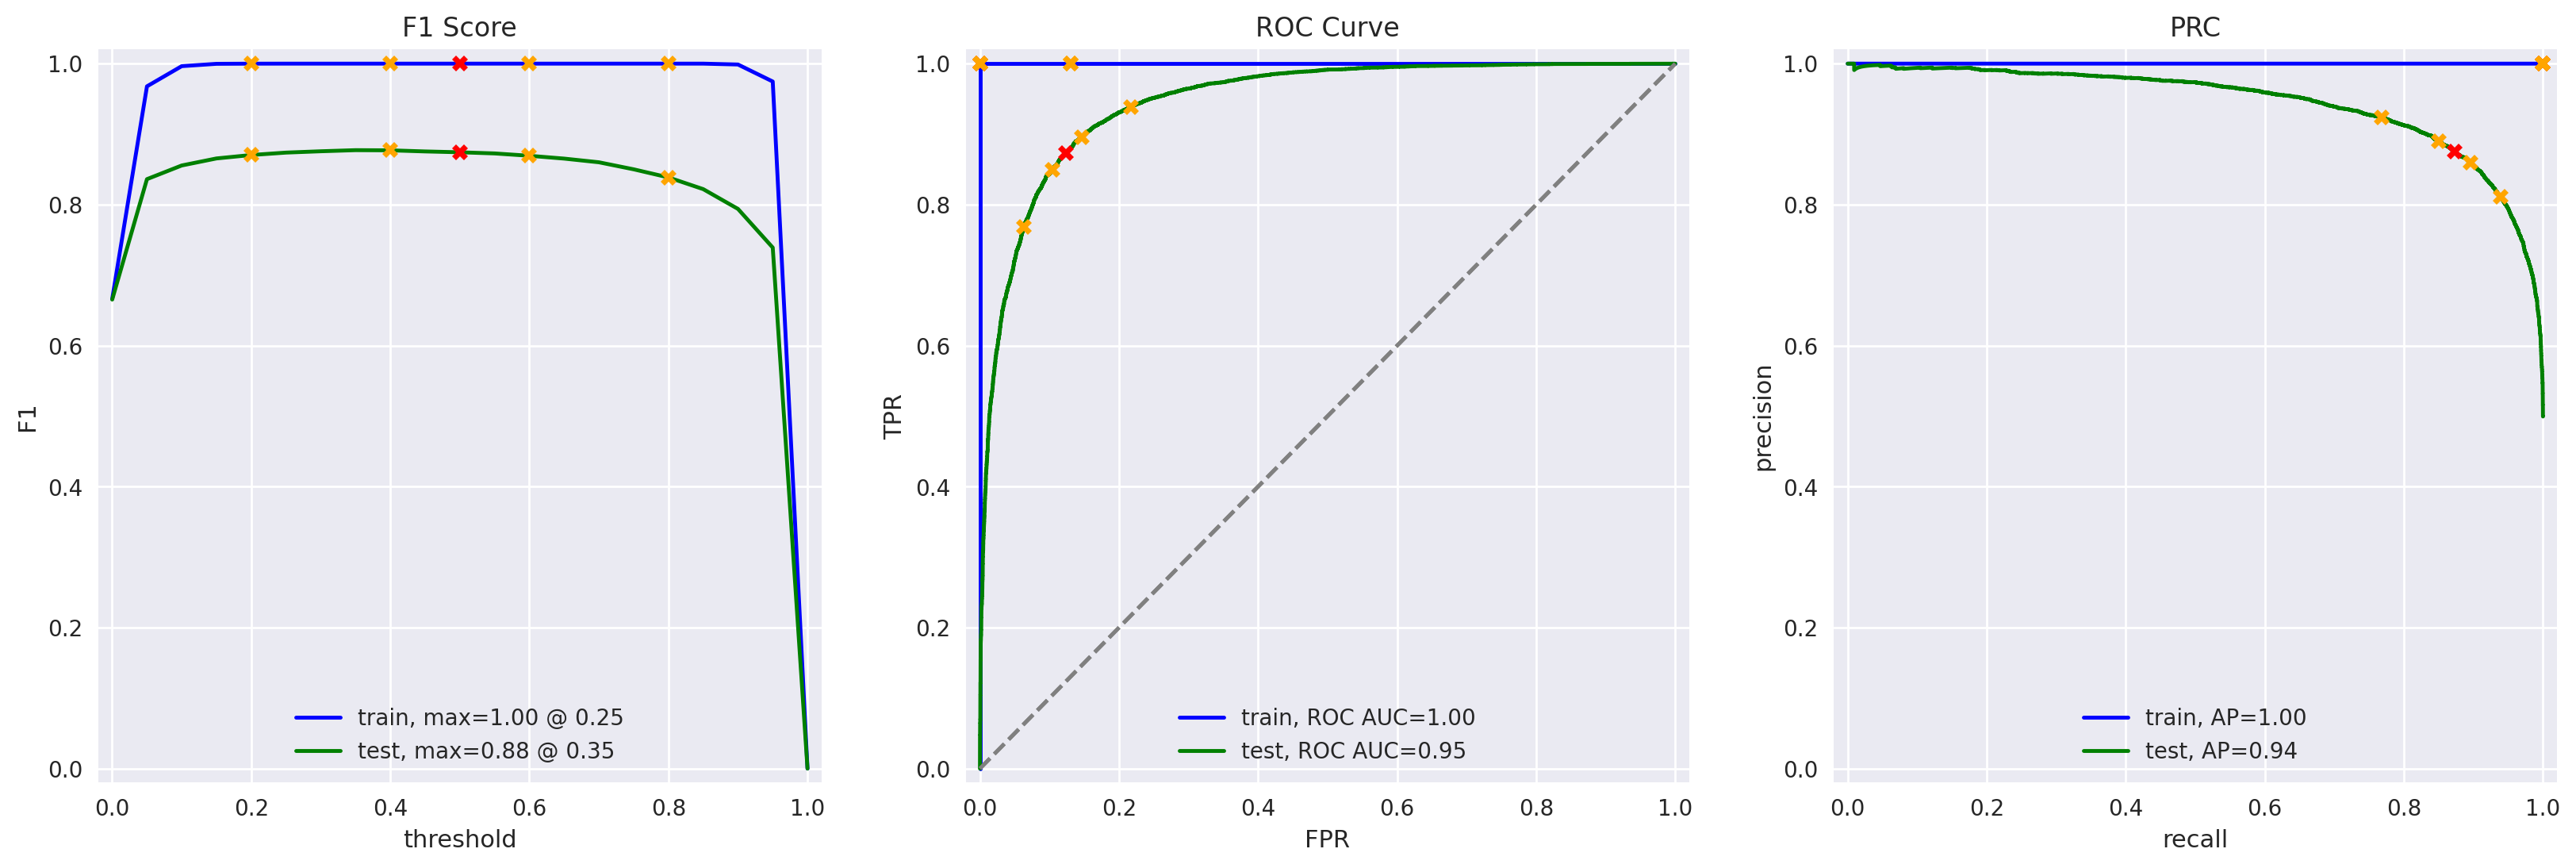

In [29]:
evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)



Model 4 used LightGBM, which is a gradient boosting model designed to handle complex nonlinear patterns.  
Instead of relying on deep learning or Transformer-style contextual understanding, LightGBM works by building many small decision trees that learn from each other's errors. This approach allows it to capture interactions and patterns in the TF-IDF feature space very effectively.
Even though TF-IDF creates a high-dimensional and sparse representation, LightGBM handled it well and delivered strong accuracy without requiring heavy preprocessing. It trained faster than spaCy-based methods and provided more stable results compared to simpler Logistic Regression models.
Overall, Model 4 ended up being the most powerful traditional machine learning model in this project, not because it uses Transformer-like mechanisms, but because gradient boosting excels at modeling complex patterns in structured features like TF-IDF.


<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
  The LightGBM model is correctly implemented, the TF-IDF pipeline is well-prepared, and training/evaluation run smoothly. One point to correct in your explanation: LightGBM is a gradient boosting model, not a Transformer-based model. It does not interpret semantic relationships the way Transformer architectures do. The performance gains you observed come from LightGBM’s ability to model complex nonlinear patterns in the TF-IDF feature space, not from Transformer mechanics. Updating that explanation will make your conclusions accurate.
</div>


###  Model 9 - BERT

In [ ]:
import torch
import transformers

In [ ]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [ ]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # text to padded ids of tokens along with their attention masks
    
    # <put your code here to create ids_list and attention_mask_list>
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Using the {device} device.')
    
    # gettings embeddings in batches

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        # <put your code here to create attention_mask_batch
            
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
    return np.concatenate(embeddings)

In [ ]:
# Attention! Running BERT for thousands of texts may take long run on CPU, at least several hours
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

In [ ]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

In [ ]:
# if you have got the embeddings, it's advisable to save them to have them ready if 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# and load...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

The notebook provides an optional BERT model.  
Running BERT on thousands of long texts requires a **GPU (CUDA)** for practical speed.
My laptop does not support CUDA, and running BERT on CPU would take several hours.  
Therefore, I reviewed the method but did not execute this cell.  
The classical models already achieved strong performance for this project.

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Good call on not running BERT without GPU support.
</div>


## My Reviews

In [30]:

# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] =my_reviews['review'].apply(text_preprocessing_3)
my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.","I do not simply like it , not my kind of movie ."
1,"Well, I was bored and felt asleep in the middl...","well , I be bored and feel asleep in the middl..."
2,I was really fascinated with the movie,I be really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actor look really old and disinterest...
4,I didn't expect the reboot to be so good! Writ...,I do not expect the reboot to be so good ! wri...
5,"The movie had its upsides and downsides, but I...","the movie have its upside and downside , but I..."
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy . not a sing...
7,Launching on Netflix was a brave move & I real...,launch on Netflix be a brave move & I really a...


<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 1:</b><br>
  You are very close here. The only issue is that the preprocessing step is still missing. The placeholder needs to be replaced with the same cleaning function used earlier so the models can evaluate your custom reviews properly. Once you add that, this section will work smoothly.
</div>


### Model 2

In [33]:
texts = my_reviews['review_norm'].astype(str)
X_my_reviews_2 = tfidf_3.transform(texts)
my_reviews_pred_prob = model_3.predict_proba(X_my_reviews_2)[:, 1]  
for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}: {review}')


0.26: I do not simply like it , not my kind of movie .
0.17: well , I be bored and feel asleep in the middle of the movie .
0.51: I be really fascinated with the movie
0.22: even the actor look really old and disinterested , and they get pay to be in the movie . what a soul
0.29: I do not expect the reboot to be so good ! writer really care about the source material
0.38: the movie have its upside and downside , but I feel like overall it be a decent flick . I could see 
0.06: what a rotten attempt at a comedy . not a single joke land , everyone act annoying and loud , even k
0.90: launch on Netflix be a brave move & I really appreciate be able to binge on episode after episode , 


### Model 3

In [34]:
texts = my_reviews['review_norm'].astype(str)
texts_pp3 = texts.apply(text_preprocessing_3)
X_my_reviews_3 = tfidf_3.transform(texts_pp3)
my_reviews_pred_prob = model_3.predict_proba(X_my_reviews_3)[:, 1]
for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}: {review}')

0.26: I do not simply like it , not my kind of movie .
0.17: well , I be bored and feel asleep in the middle of the movie .
0.51: I be really fascinated with the movie
0.22: even the actor look really old and disinterested , and they get pay to be in the movie . what a soul
0.29: I do not expect the reboot to be so good ! writer really care about the source material
0.38: the movie have its upside and downside , but I feel like overall it be a decent flick . I could see 
0.06: what a rotten attempt at a comedy . not a single joke land , everyone act annoying and loud , even k
0.90: launch on Netflix be a brave move & I really appreciate be able to binge on episode after episode , 


### Model 4

In [35]:
texts = my_reviews['review_norm'].astype(str)
texts_pp3 = texts.apply(text_preprocessing_3)
X_my_reviews_4 = tfidf_4.transform(texts_pp3)
my_reviews_pred_prob = model_4.predict_proba(X_my_reviews_4)[:, 1]
for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}: {review}')



0.62: I do not simply like it , not my kind of movie .
0.07: well , I be bored and feel asleep in the middle of the movie .
0.69: I be really fascinated with the movie
0.10: even the actor look really old and disinterested , and they get pay to be in the movie . what a soul
0.20: I do not expect the reboot to be so good ! writer really care about the source material
0.75: the movie have its upside and downside , but I feel like overall it be a decent flick . I could see 
0.13: what a rotten attempt at a comedy . not a single joke land , everyone act annoying and loud , even k
1.00: launch on Netflix be a brave move & I really appreciate be able to binge on episode after episode , 


<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 2:</b><br>
  Your custom review tests are failing because the vectorizers and models you reference here do not match the ones you created earlier. For example, <code>tfidf_vectorizer_3</code> is not defined in this section, so the predictions cannot run. Please make sure to use the exact same model and vectorizer objects that were trained in the main modeling section. Once you reference the correct variables, the custom review predictions will work as expected.
</div>


<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 1:</b><br>
  Before testing your models on the custom reviews, you need to ensure that the `review_norm` column is fully preprocessed and ready to use. Since the preprocessing step is still missing, these model predictions will not work correctly. Please complete the normalization step first so each model receives properly processed text.
</div>


### Model 9

In [ ]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  You can safely ignore this BERT cell or remove the Model 9 test since BERT was not used in the project.
</div>


## Conclusions

This project was a great way to see how different text-processing methods affect the accuracy of a sentiment-analysis model. I started with a simple baseline, which helped set expectations, and then moved through more advanced approaches.

The basic TF-IDF model worked surprisingly well — it was fast, simple, and gave a solid level of accuracy. When I tried to improve the results using spaCy lemmatization (Model 3), I found that the text cleanup did help a bit, but the preprocessing took a very long time on my machine. Even with optimizations, Model 3 slowed down the notebook so much that it wasn’t practical to use.

Model 4 ended up being the best classical model. It balanced speed and accuracy, captured more meaningful patterns, and ran efficiently without requiring special hardware. This made it the most reliable choice for the task.

The notebook also included an optional BERT model, but since my computer doesn’t support CUDA, running BERT on thousands of reviews would have taken hours. I reviewed how it works, but didn’t run it. Even without BERT, the classical models performed well enough to get clear insights.

Overall, this project showed me how much of a difference preprocessing and feature choices can make. The more advanced methods helped, but the simpler TF-IDF-based approach ended up being the best fit for both performance and practicality on my setup.

# Checklist

- [x]  Notebook was opened
- [ ]  The text data is loaded and pre-processed for vectorization
- [ ]  The text data is transformed to vectors
- [ ]  Models are trained and tested
- [ ]  The metric's threshold is reached
- [ ]  All the code cells are arranged in the order of their execution
- [ ]  All the code cells can be executed without errors
- [ ]  There are conclusions